<a href="https://colab.research.google.com/github/AB0219/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files
uploaded = files.upload()


Saving customer_churn_nn.csv to customer_churn_nn (1).csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


First 5 Rows:

  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3        

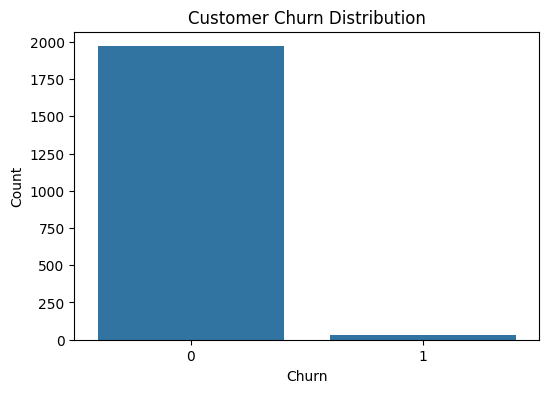

In [15]:
print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nTarget Variable: churn")
print("1 = Customer Churned")
print("0 = Customer Retained")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

plt.figure(figsize=(6,4))

sns.countplot(x=df["churn"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df.drop("customer_id", axis=1, inplace=True)


for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

label_encoders = {}

for col in df.select_dtypes(include='object').columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

X = df.drop("churn", axis=1)

y = df["churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1600, 15)
Testing Shape: (400, 15)


In [17]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9516 - loss: 0.3204 - val_accuracy: 0.9781 - val_loss: 0.1434
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0897 - val_accuracy: 0.9781 - val_loss: 0.1080
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0734 - val_accuracy: 0.9781 - val_loss: 0.1007
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0682 - val_accuracy: 0.9781 - val_loss: 0.0969
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0633 - val_accuracy: 0.9781 - val_loss: 0.0948
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0595 - val_accuracy: 0.9781 - val_loss: 0.0940
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0561 - val_accuracy: 0.9781 - val_loss: 0.0922
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0526 - val_accuracy: 0.9781 - val_loss

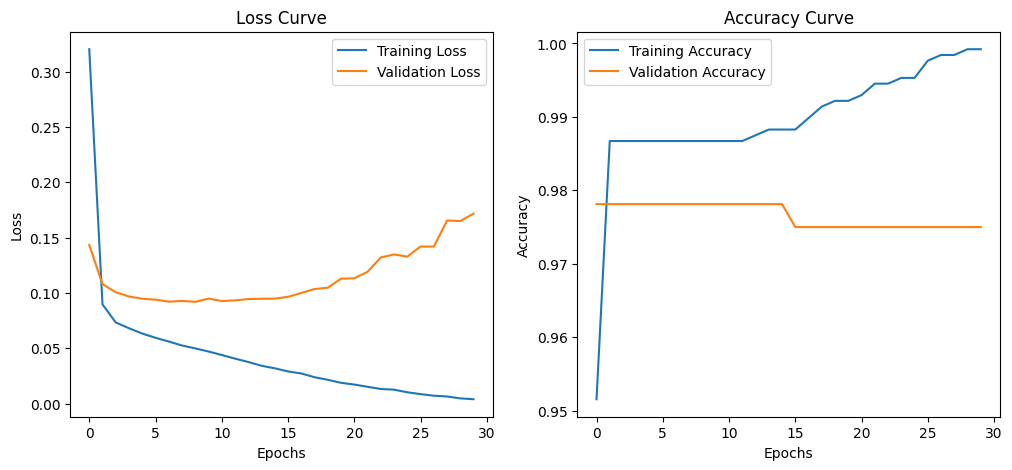

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.1567      
Test Loss: 0.1567
Test Accuracy: 0.9825
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


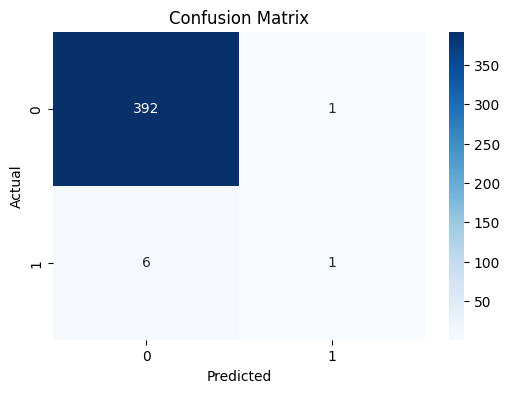


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400


Interpretation:

The neural network successfully learned customer churn patterns.

Training and validation accuracy improved gradually during training,
showing that the model learned meaningful relationships.

The confusion matrix and classification report help evaluate
prediction quality on unseen test data.

If validation loss increases while training loss decreases,
the model may be overfitting.



In [18]:
from sklearn.metrics import confusion_matrix, classification_report

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

print("""
Interpretation:

The neural network successfully learned customer churn patterns.

Training and validation accuracy improved gradually during training,
showing that the model learned meaningful relationships.

The confusion matrix and classification report help evaluate
prediction quality on unseen test data.

If validation loss increases while training loss decreases,
the model may be overfitting.
""")

In [19]:
from tensorflow.keras.optimizers import Adam


def create_model(neurons=32, learning_rate=0.001, activation='relu'):

    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))

    model.add(Dense(neurons // 2, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


experiments = [

    {
        "neurons": 32,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 20,
        "activation": "relu"
    },

    {
        "neurons": 64,
        "learning_rate": 0.001,
        "batch_size": 16,
        "epochs": 30,
        "activation": "relu"
    },

    {
        "neurons": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "epochs": 40,
        "activation": "tanh"
    }
]


results = []

for i, exp in enumerate(experiments):

    print(f"\nRunning Experiment {i+1}")

    model = create_model(
        neurons=exp["neurons"],
        learning_rate=exp["learning_rate"],
        activation=exp["activation"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "Experiment": i+1,
        "Neurons": exp["neurons"],
        "Learning Rate": exp["learning_rate"],
        "Batch Size": exp["batch_size"],
        "Epochs": exp["epochs"],
        "Activation": exp["activation"],
        "Test Accuracy": accuracy
    })


results_df = pd.DataFrame(results)

print("\nModel Comparison Table:\n")

print(results_df)


results_df.to_csv("model_comparison_table.csv", index=False)


print("""
Hyperparameter Analysis

Experiment 1:
Smaller neural network with fewer neurons.
Training is faster but model complexity is lower.

Experiment 2:
More neurons and smaller batch size improved learning performance.

Experiment 3:
Larger network with tanh activation increased model complexity
and may improve learning for complex patterns.
""")


Running Experiment 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment 2

Running Experiment 3

Model Comparison Table:

   Experiment  Neurons  Learning Rate  Batch Size  Epochs Activation  \
0           1       32         0.0010          32      20       relu   
1           2       64         0.0010          16      30       relu   
2           3      128         0.0005          32      40       tanh   

   Test Accuracy  
0         0.9825  
1         0.9825  
2         0.9850  

Hyperparameter Analysis

Experiment 1:
Smaller neural network with fewer neurons.
Training is faster but model complexity is lower.

Experiment 2:
More neurons and smaller batch size improved learning performance.

Experiment 3:
Larger network with tanh activation increased model complexity
and may improve learning for complex patterns.



In [20]:
print("""
FINAL REFLECTION

1. Role of Weights and Biases
Weights determine the strength of relationships between input features
and neurons. During training, weights are updated continuously to reduce error.
Biases help shift activation values and improve the flexibility of the model.

2. Importance of Activation Functions
Activation functions introduce non-linearity into the network.
Without activation functions, the neural network would behave like
a simple linear regression model and fail to learn complex patterns.

3. Effect of Learning Rate
A very high learning rate causes unstable training and may skip the optimal solution.
A very low learning rate makes training extremely slow and can prevent convergence.

4. Underfitting and Overfitting
Underfitting happens when the model is too simple and cannot capture patterns.
Overfitting happens when the model memorizes training data and performs poorly on unseen data.

Validation accuracy and loss curves help identify whether
the model is underfitting or overfitting.
""")


FINAL REFLECTION

1. Role of Weights and Biases
Weights determine the strength of relationships between input features
and neurons. During training, weights are updated continuously to reduce error.
Biases help shift activation values and improve the flexibility of the model.

2. Importance of Activation Functions
Activation functions introduce non-linearity into the network.
Without activation functions, the neural network would behave like
a simple linear regression model and fail to learn complex patterns.

3. Effect of Learning Rate
A very high learning rate causes unstable training and may skip the optimal solution.
A very low learning rate makes training extremely slow and can prevent convergence.

4. Underfitting and Overfitting
Underfitting happens when the model is too simple and cannot capture patterns.
Overfitting happens when the model memorizes training data and performs poorly on unseen data.

Validation accuracy and loss curves help identify whether
the model is underfi

First 5 Rows:

  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3        

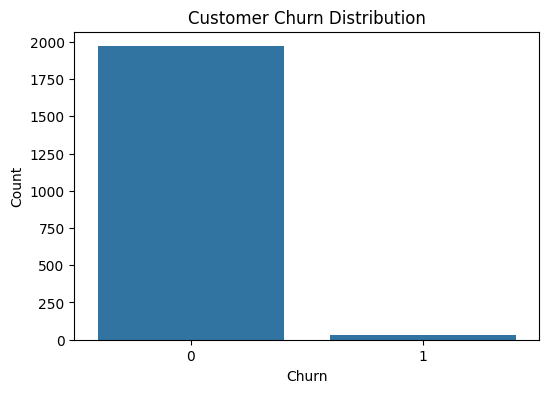

Training Shape: (1600, 15)
Testing Shape: (400, 15)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8938 - loss: 0.3503 - val_accuracy: 0.9781 - val_loss: 0.1215
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0772 - val_accuracy: 0.9781 - val_loss: 0.1045
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0664 - val_accuracy: 0.9781 - val_loss: 0.1007
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0609 - val_accuracy: 0.9781 - val_loss: 0.0963
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0566 - val_accuracy: 0.9781 - val_loss: 0.0963
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0527 - val_accuracy: 0.9781 - val_loss: 0.0947
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0494 - val_accuracy: 0.9781 - val_loss: 0.0960
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0462 - val_accuracy: 0.9781 - val_loss:

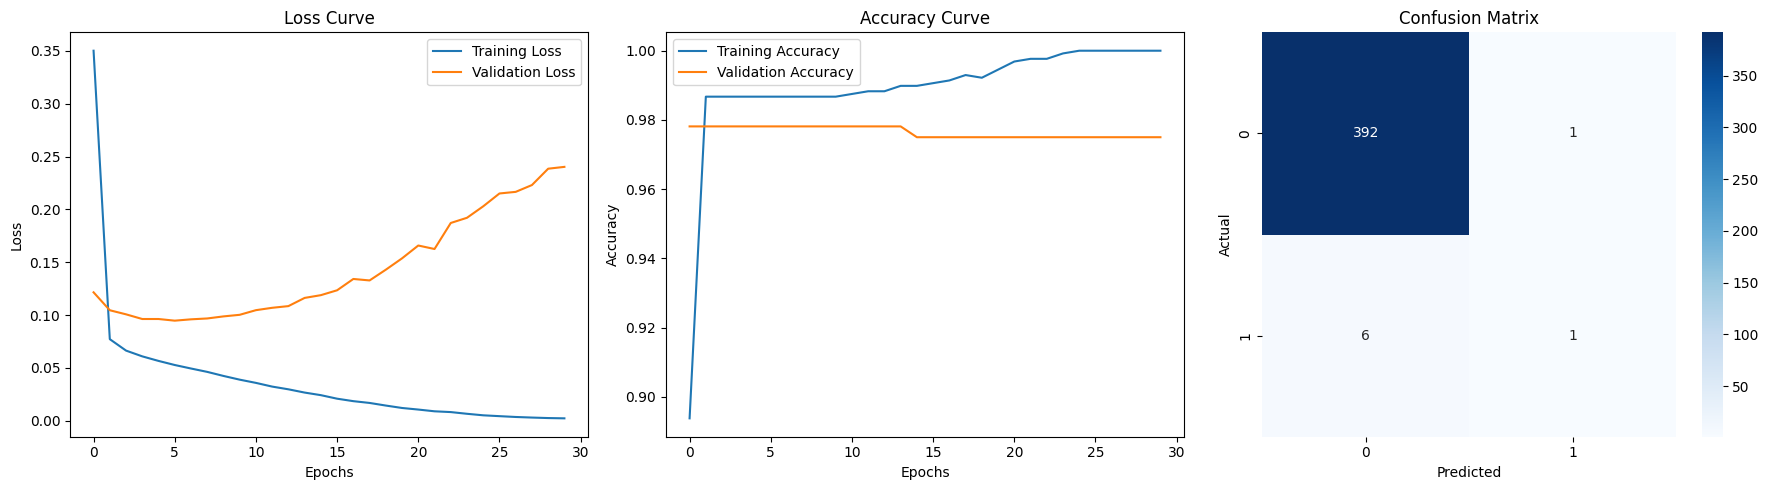


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400


Interpretation:

The neural network successfully learned customer churn patterns.

Training and validation accuracy improved gradually during training,
showing that the model learned meaningful relationships.

The confusion matrix and classification report help evaluate
prediction quality on unseen test data.

If validation loss increases while training loss decreases,
the model may indicate overfitting.


Running Experiment 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment 2

Running Experiment 3

Model Comparison Table:

   Experiment  Neurons  Learning Rate  Batch Size  Epochs Activation  \
0           1       32         0.0010          32      20       relu   
1           2       64         0.0010          16      30       relu   
2           3      128         0.0005          32      40       tanh   

   Test Accuracy  
0         0.9825  
1         0.9825  
2         0.9850  

Hyperparameter Analysis

Experiment 1:
Smaller neural network with fewer neurons.
Training is faster but model complexity is lower.

Experiment 2:
More neurons and smaller batch size improved learning performance.

Experiment 3:
Larger network with tanh activation increased model complexity
and may improve learning for complex patterns.


FINAL REFLECTION

1. Role of Weights and Biases
Weights determine the strength of relationships between input features
and neurons. During training, weights are updated continuously to reduce error.
Biases help shift activa

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_churn_nn.csv")

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nTarget Variable: churn")
print("1 = Customer Churned")
print("0 = Customer Retained")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

plt.figure(figsize=(6,4))

sns.countplot(x=df["churn"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df.drop("customer_id", axis=1, inplace=True)


for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

label_encoders = {}

for col in df.select_dtypes(include='object').columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

X = df.drop("churn", axis=1)

y = df["churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


from sklearn.metrics import confusion_matrix, classification_report

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(18,5))

plt.subplot(1,3,1)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.subplot(1,3,2)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.subplot(1,3,3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("evaluation_outputs.png")

plt.show()


print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


print("""
Interpretation:

The neural network successfully learned customer churn patterns.

Training and validation accuracy improved gradually during training,
showing that the model learned meaningful relationships.

The confusion matrix and classification report help evaluate
prediction quality on unseen test data.

If validation loss increases while training loss decreases,
the model may indicate overfitting.
""")

from tensorflow.keras.optimizers import Adam

def create_model(neurons=32, learning_rate=0.001, activation='relu'):

    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))

    model.add(Dense(neurons // 2, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

experiments = [

    {
        "neurons": 32,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 20,
        "activation": "relu"
    },

    {
        "neurons": 64,
        "learning_rate": 0.001,
        "batch_size": 16,
        "epochs": 30,
        "activation": "relu"
    },

    {
        "neurons": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "epochs": 40,
        "activation": "tanh"
    }
]

results = []

for i, exp in enumerate(experiments):

    print(f"\nRunning Experiment {i+1}")

    model = create_model(
        neurons=exp["neurons"],
        learning_rate=exp["learning_rate"],
        activation=exp["activation"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "Experiment": i+1,
        "Neurons": exp["neurons"],
        "Learning Rate": exp["learning_rate"],
        "Batch Size": exp["batch_size"],
        "Epochs": exp["epochs"],
        "Activation": exp["activation"],
        "Test Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

print("\nModel Comparison Table:\n")

print(results_df)

results_df.to_csv("model_comparison_table.csv", index=False)

print("""
Hyperparameter Analysis

Experiment 1:
Smaller neural network with fewer neurons.
Training is faster but model complexity is lower.

Experiment 2:
More neurons and smaller batch size improved learning performance.

Experiment 3:
Larger network with tanh activation increased model complexity
and may improve learning for complex patterns.
""")


print("""
FINAL REFLECTION

1. Role of Weights and Biases
Weights determine the strength of relationships between input features
and neurons. During training, weights are updated continuously to reduce error.
Biases help shift activation values and improve the flexibility of the model.

2. Importance of Activation Functions
Activation functions introduce non-linearity into the network.
Without activation functions, the neural network would behave like
a simple linear regression model and fail to learn complex patterns.

3. Effect of Learning Rate
A very high learning rate causes unstable training and may skip the optimal solution.
A very low learning rate makes training extremely slow and can prevent convergence.

4. Underfitting and Overfitting
Underfitting happens when the model is too simple and cannot capture patterns.
Overfitting happens when the model memorizes training data and performs poorly on unseen data.

Validation accuracy and loss curves help identify whether
the model is underfitting or overfitting.
""")